# Part 2 – Preprocessing for demand forecasting (v1.0)
Armani Middle East Trading technical assessment · **Part 2, step 1: prepare the forecasting dataset**

**Why this step is needed.** The ETL v1.1 review showed that weekly sales are `min(demand, stock available)`: sales never exceed the previous row's inventory, so in stock-out / stock-limited weeks the observed sales understate real demand. Forecasting raw sales would therefore forecast *stock availability*, not demand. This notebook
1. classifies every week as **unconstrained** (sales = true demand), **stock-limited**, **stock-out** or **stock-unknown**;
2. validates the legacy `Demand_Forecast` as a measure of true demand (on unconstrained weeks);
3. **reconstructs a demand target** (`demand_est`) – free parameters of the models are tuned by cross-validation on the training data only;
4. tests **calendar effects** (week / month / quarter / season) on demand, price, COGS, margin and stock;
5. profiles products (shape similarity, growth, stock regimes) to inform the modelling approaches;
6. writes the forecasting dataset (`forecast_dataset_v1.0.db`) and one Excel workbook with all results.

Input: `part1_etl_pipeline_v1.1/armani_trade_v1.1.db` (run `part1_etl_pipeline_v1.1.ipynb` first). Output folder: `part2_preprocessing_v1.0/`.

In [1]:
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.cluster import AgglomerativeClustering, KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

%matplotlib inline
warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
plt.rcParams.update({"figure.dpi": 100, "axes.spines.top": False, "axes.spines.right": False})
BLUE, ORANGE, GREY, RED, GREEN = "#2c7fb8", "#e08214", "#7f7f7f", "#c0392b", "#2e8b57"

VERSION = "v1.0"                       # appended to the name of every generated file
HERE = Path.cwd()
ETL_DB = HERE / "part1_etl_pipeline_v1.1" / "armani_trade_v1.1.db"
OUT = HERE / "part2_preprocessing_v1.0"           # created by this notebook
FIG = OUT / "figures"
FIG.mkdir(parents=True, exist_ok=True)
DB_OUT = OUT / f"forecast_dataset_{VERSION}.db"
XLSX_PATH = OUT / f"preprocessing_results_{VERSION}.xlsx"

CFG = {
    "seed": 42,
    "n_folds": 5,                       # blocked cross-validation folds
    "block_weeks": 4,                   # contiguous weeks kept together in a fold
    "k_grid": list(range(1, 11)),       # candidate Fourier orders (free parameter)
    "trend_modes": ["shared", "per_product"],   # candidate trend structures (free parameter)
    "horizon_weeks": 26,
    "n_perm": 100,                      # permutations for the calendar-effect test
    "start_date": "2020-01-06",         # synthetic calendar (same assumption as the ETL)
}
rng = np.random.default_rng(CFG["seed"])

## 1. Load the clean data from the ETL database

In [2]:
def load_inputs(db_path):
    if not Path(db_path).exists():
        raise FileNotFoundError(f"{db_path} not found - run part1_etl_pipeline_v1.1.ipynb first")
    con = sqlite3.connect(db_path)
    try:
        panel = pd.read_sql("SELECT * FROM vw_sales_enriched", con)
        prods = pd.read_sql("SELECT * FROM dim_product", con)
    finally:
        con.close()
    return panel.sort_values(["product_id", "week_id"]).reset_index(drop=True), prods


df, dim_prod = load_inputs(ETL_DB)
df["year_index"] = (df.week_id - 1) // 52 + 1          # data year 1..5 (not exposed by the ETL view)
# integrity checks on the input
assert len(df) == 30 * 260 and df.product_id.nunique() == 30, "unexpected panel shape"
assert df.sales_units.notna().all()
assert not (df.sales_units > df.stock_available_for_sales).any(), "sales exceed available stock"
print(f"{len(df):,} rows | {df.product_id.nunique()} products | weeks {df.week_id.min()}-{df.week_id.max()}")
df.head(3)

7,800 rows | 30 products | weeks 1-260


,sales_id,product_id,product_name,product_category,inventory_profile,week_id,week_start_date,year,quarter,month,week_of_year,season,sales_units,sales_units_winsorized,unit_price,unit_cogs,inventory_level,stock_available_for_sales,demand_forecast_legacy,revenue,gross_profit,operating_profit,implied_opex,gross_profit_margin,inventory_turnover,revenue_growth,flag_sales_imputed,flag_zero_sales,flag_sales_pileup,flag_inventory_pileup,flag_stockout_week,flag_stock_limited,flag_stock_unknown,flag_sales_outlier,flag_forecast_missing,year_index
0,1,1,Barley,Cereals & Grains,normal,1,2020-01-06,2020,1,1,1,Winter,2669,2669.0,8.03,5.98,2500,NaN,2811.0,21432.07,5471.45,3754.78,1716.67,0.2553,NaN,NaN,0,0,0,1,0,0,1,0,0,1
1,2,1,Barley,Cereals & Grains,normal,2,2020-01-13,2020,1,1,2,Winter,2500,2500.0,7.82,6.00,1500,2500.0,2733.0,19550.00,4550.00,2750.07,1799.93,0.2327,1.0,-0.0878,0,0,1,1,0,1,0,0,0,1
2,3,1,Barley,Cereals & Grains,normal,3,2020-01-20,2020,1,1,3,Winter,1500,1500.0,6.98,5.70,0,1500.0,2502.0,10470.00,1920.00,682.01,1237.99,0.1834,1.0,-0.4645,0,0,1,1,0,1,0,0,0,1


## 2. Classify every week by stock censoring
* **unconstrained** – sales < stock available → sales = true demand
* **stock_limited** – sales = stock available (> 0) → true demand ≥ sales
* **stockout** – stock available = 0 → sales = 0, true demand unknown (> 0)
* **stock_unknown** – first week of each product (no previous inventory)

In [3]:
df["censor_status"] = np.select(
    [df.flag_stock_unknown == 1, df.flag_stockout_week == 1, df.flag_stock_limited == 1],
    ["stock_unknown", "stockout", "stock_limited"], default="unconstrained")
df["is_censored"] = df.censor_status.isin(["stockout", "stock_limited"]).astype(int)

order = ["unconstrained", "stock_limited", "stockout", "stock_unknown"]
cens_overall = df.censor_status.value_counts().reindex(order).rename("rows").to_frame()
cens_overall["pct"] = (100 * cens_overall.rows / len(df)).round(1)
cens_by_profile = pd.crosstab(df.inventory_profile, df.censor_status, normalize="index").reindex(columns=order).mul(100).round(1)
cens_by_product = (pd.crosstab(df.product_name, df.censor_status, normalize="index").reindex(columns=order).mul(100).round(1)
                   .join(dim_prod.set_index("product_name").inventory_profile).sort_values("unconstrained"))
display(cens_overall); display(cens_by_profile)

,rows,pct
censor_status,,
unconstrained,3628,46.5
stock_limited,2813,36.1
stockout,1329,17.0
stock_unknown,30,0.4


censor_status,unconstrained,stock_limited,stockout,stock_unknown
inventory_profile,,,,
high_stock,98.8,0.4,0.3,0.4
normal,30.6,46.9,22.1,0.4


## 3. Is the legacy `Demand_Forecast` a usable measure of true demand?
On **unconstrained** weeks the true demand is known (= sales), so the legacy forecast can be checked against it without bias from censoring.

In [4]:
def metrics(actual, pred):
    err = pred - actual
    return {"n": int(len(actual)), "MAE": float(np.mean(np.abs(err))), "RMSE": float(np.sqrt(np.mean(err ** 2))),
            "MAPE_%": float(100 * np.mean(np.abs(err) / actual)), "bias": float(np.mean(err)),
            "bias_%": float(100 * np.mean(err / actual)), "corr": float(np.corrcoef(actual, pred)[0, 1])}


u = df[(df.censor_status == "unconstrained") & df.demand_forecast_legacy.notna()].copy()
u["ratio"] = u.demand_forecast_legacy / u.sales_units
legacy_overall = pd.DataFrame({"unconstrained weeks": metrics(u.sales_units, u.demand_forecast_legacy)}).T
legacy_overall["ratio_sd"] = u.ratio.std()
legacy_by_product = (u.groupby("product_name").apply(lambda g: pd.Series(metrics(g.sales_units, g.demand_forecast_legacy)))
                     .round(3).join(dim_prod.set_index("product_name").inventory_profile))
c = df[(df.is_censored == 1) & df.demand_forecast_legacy.notna()]
fc_vs_censored = pd.DataFrame({
    "metric": ["censored weeks with forecast", "forecast >= observed sales (share)", "mean forecast", "mean observed sales"],
    "value": [len(c), round((c.demand_forecast_legacy >= c.sales_units).mean(), 3), round(c.demand_forecast_legacy.mean()), round(c.sales_units.mean())]})
display(legacy_overall.round(3)); display(fc_vs_censored)
print("Relative error is roughly level-independent (multiplicative noise):",
      "corr(|err|, sales) =", round(np.corrcoef((u.demand_forecast_legacy - u.sales_units).abs(), u.sales_units)[0, 1], 2),
      "| corr(|err|/sales, sales) =", round(np.corrcoef(((u.demand_forecast_legacy - u.sales_units).abs() / u.sales_units), u.sales_units)[0, 1], 2))

,n,MAE,RMSE,MAPE_%,bias,bias_%,corr,ratio_sd
unconstrained weeks,3347.0,110.741,151.057,7.939,-3.617,-0.35,0.97,0.099


,metric,value
0,censored weeks with forecast,3819.000
1,forecast >= observed sales (share),0.967
2,mean forecast,2631.000
3,mean observed sales,1119.000


Relative error is roughly level-independent (multiplicative noise): corr(|err|, sales) = 0.48 | corr(|err|/sales, sales) = 0.01


**Reading:** on weeks where stock did not limit sales, the legacy forecast is unbiased with ≈ ±10 % multiplicative noise → it is a good *noisy measure of true demand*. On censored weeks it is mostly **above** the observed sales, exactly what a demand measure should do.

## 4. Reconstruct the demand target (`demand_est`)
| Week type | Demand used | `demand_source` |
|---|---|---|
| unconstrained | observed sales | `observed` |
| censored / unknown, forecast available | `max(sales, blend of legacy forecast and seasonal model)` | `forecast_blend` |
| censored / unknown, forecast missing | `max(sales, seasonal model)` | `model_only` |

The **seasonal model** (shared yearly curve + product level + trend, in log space) has free parameters – the Fourier order `K` and the trend structure – which are **optimised by blocked cross-validation on the training data** (held-out blocks of weeks, scored on held-out *observed* demand). The **blend weight** `w` between legacy forecast and model is estimated from out-of-fold predictions on observed weeks.

In [5]:
PIDS = np.sort(df.product_id.unique())


def make_design(d, K, trend_mode):
    P = (d.product_id.values[:, None] == PIDS[None, :]).astype(float)       # product level (one-hot, no global intercept)
    t = ((d.week_id.values - 130) / 260.0)[:, None]
    trend = t * P if trend_mode == "per_product" else t
    ang = 2 * np.pi * d.week_of_year.values[:, None] * np.arange(1, K + 1)[None, :] / 52
    return np.hstack([P, trend, np.sin(ang), np.cos(ang)])


def fit_predict(train, test, K, trend_mode):
    """Log-linear model with shared Fourier seasonality; predictions are mean-corrected (smearing)."""
    X, y = make_design(train, K, trend_mode), np.log(train.dem_reliable.values)
    beta = np.linalg.lstsq(X, y, rcond=None)[0]
    smear = np.exp(np.var(y - X @ beta) / 2)
    return np.exp(make_design(test, K, trend_mode) @ beta) * smear


# 'reliable' demand values = training targets for the seasonal model
df["dem_reliable"] = np.where(df.censor_status == "unconstrained", df.sales_units, np.nan)
cm = df.is_censored.eq(1) & df.demand_forecast_legacy.notna()
df.loc[cm, "dem_reliable"] = np.maximum(df.loc[cm, "demand_forecast_legacy"], df.loc[cm, "sales_units"])
reliable = df.dem_reliable.notna()
print(f"reliable training targets: {int(reliable.sum()):,} of {len(df):,} rows")

# blocked folds: contiguous 4-week blocks assigned randomly to 5 folds (same for all products)
blocks = ((df.week_id - 1) // CFG["block_weeks"]).values
fold_of_block = rng.permutation(np.arange(blocks.max() + 1) % CFG["n_folds"])
df["fold"] = fold_of_block[blocks]
obs = (df.censor_status == "unconstrained").values          # held-out scoring uses OBSERVED demand only

cv_rows = []
for K in CFG["k_grid"]:
    for mode in CFG["trend_modes"]:
        fold_mape = []
        for f in range(CFG["n_folds"]):
            tr = df[(df.fold != f) & reliable]
            te = df[(df.fold == f) & obs]
            p = fit_predict(tr, te, K, mode)
            fold_mape.append(100 * np.mean(np.abs(p - te.sales_units.values) / te.sales_units.values))
        cv_rows.append({"K": K, "trend": mode, "n_params": len(PIDS) * (2 if mode == "per_product" else 1) + (0 if mode == "per_product" else 1) + 2 * K,
                        "cv_MAPE_%": np.mean(fold_mape), "cv_SE": np.std(fold_mape, ddof=1) / np.sqrt(len(fold_mape))})
imp_cv = pd.DataFrame(cv_rows)
best = imp_cv.loc[imp_cv["cv_MAPE_%"].idxmin()]
# one-standard-error rule: simplest configuration within 1 SE of the best
cand = imp_cv[imp_cv["cv_MAPE_%"] <= best["cv_MAPE_%"] + best["cv_SE"]].sort_values(["n_params", "K"])
chosen = cand.iloc[0]
K_OPT, TREND_OPT = int(chosen.K), chosen.trend
imp_cv["selected"] = (imp_cv.K == K_OPT) & (imp_cv.trend == TREND_OPT)
print(f"best CV MAPE {best['cv_MAPE_%']:.2f}% (K={int(best.K)}, trend={best.trend}) -> 1-SE rule selects K={K_OPT}, trend={TREND_OPT} "
      f"(CV MAPE {chosen['cv_MAPE_%']:.2f}%)")
imp_cv.round(3)

reliable training targets: 7,447 of 7,800 rows


best CV MAPE 6.66% (K=2, trend=shared) -> 1-SE rule selects K=2, trend=shared (CV MAPE 6.66%)


,K,trend,n_params,cv_MAPE_%,cv_SE,selected
0,1,shared,33,6.699,0.051,False
1,1,per_product,62,6.714,0.062,False
2,2,shared,35,6.658,0.030,True
3,2,per_product,64,6.674,0.039,False
4,3,shared,37,6.661,0.029,False
5,3,per_product,66,6.675,0.038,False
6,4,shared,39,6.659,0.029,False
7,4,per_product,68,6.673,0.038,False
8,5,shared,41,6.664,0.031,False
9,5,per_product,70,6.677,0.040,False


In [6]:
# out-of-fold predictions with the selected configuration (for validation and blend weight)
df["oof_pred"] = np.nan
for f in range(CFG["n_folds"]):
    tr = df[(df.fold != f) & reliable]
    te = df[df.fold == f]
    df.loc[te.index, "oof_pred"] = fit_predict(tr, te, K_OPT, TREND_OPT)

# blend weight: log(sales) ~ (1-w) log(model) + w log(forecast), estimated on observed weeks with a forecast
b = df[obs & df.demand_forecast_legacy.notna()]
yl, fl, pl = np.log(b.sales_units), np.log(b.demand_forecast_legacy), np.log(b.oof_pred)
W = float(np.clip(np.sum((yl - pl) * (fl - pl)) / np.sum((fl - pl) ** 2), 0, 1))
# robustness: estimate w on half of the products and evaluate on the other half (and vice versa)
halves = np.array_split(rng.permutation(PIDS), 2)
w_halves = []
for tr_p, te_p in [(halves[0], halves[1]), (halves[1], halves[0])]:
    a = b[b.product_id.isin(tr_p)]
    w_h = float(np.clip(np.sum((np.log(a.sales_units) - np.log(a.oof_pred)) * (np.log(a.demand_forecast_legacy) - np.log(a.oof_pred))) /
                        np.sum((np.log(a.demand_forecast_legacy) - np.log(a.oof_pred)) ** 2), 0, 1))
    t_ = b[b.product_id.isin(te_p)]
    bl = np.exp(w_h * np.log(t_.demand_forecast_legacy) + (1 - w_h) * np.log(t_.oof_pred))
    w_halves.append((w_h, metrics(t_.sales_units.values, bl.values)["MAPE_%"]))
blend_oof = np.exp(W * fl + (1 - W) * pl)
recon_validation = pd.DataFrame({
    "legacy forecast only": metrics(b.sales_units.values, b.demand_forecast_legacy.values),
    "seasonal model only (out-of-fold)": metrics(b.sales_units.values, b.oof_pred.values),
    f"blend (w = {W:.2f} on forecast)": metrics(b.sales_units.values, blend_oof.values),
}).T.round(3)
print(f"blend weight on legacy forecast w = {W:.3f} | cross-product check: w={w_halves[0][0]:.2f}/{w_halves[1][0]:.2f}, "
      f"held-out blend MAPE {w_halves[0][1]:.2f}% / {w_halves[1][1]:.2f}%")
recon_validation

blend weight on legacy forecast w = 0.400 | cross-product check: w=0.40/0.40, held-out blend MAPE 5.06% / 5.00%


,n,MAE,RMSE,MAPE_%,bias,bias_%,corr
legacy forecast only,3347.0,110.741,151.057,7.939,-3.617,-0.350,0.970
seasonal model only (out-of-fold),3347.0,90.882,123.776,6.634,14.673,1.368,0.980
blend (w = 0.40 on forecast),3347.0,69.516,94.128,5.030,4.493,0.472,0.988


**Reading:** the table scores each reconstruction method on *observed* weeks whose true demand is known (the model numbers are out-of-fold). The blend combines the forecast's week-specific information with the model's noise-free seasonal level; its weight was fitted on training weeks only and holds up on products it was not fitted on.

In [7]:
# final model on all reliable rows -> predictions for every row, then the demand target
df["model_pred"] = fit_predict(df[reliable], df, K_OPT, TREND_OPT)
fc = df.demand_forecast_legacy
blend = np.exp(W * np.log(fc.where(fc > 0)) + (1 - W) * np.log(df.model_pred))
cand_dem = np.where(fc.notna(), blend, df.model_pred)
censored_or_unknown = df.censor_status != "unconstrained"
df["demand_est"] = np.where(censored_or_unknown, np.maximum(cand_dem, df.sales_units), df.sales_units)
df["demand_source"] = np.select([~censored_or_unknown, fc.notna()], ["observed", "forecast_blend"], default="model_only")
df["demand_uplift_pct"] = np.where(df.sales_units > 0, 100 * (df.demand_est / df.sales_units - 1), np.nan)

src_counts = (df.groupby(["inventory_profile", "demand_source"]).size().unstack(fill_value=0)
              .assign(total=lambda x: x.sum(axis=1)))
src_counts.loc["all products"] = src_counts.sum()
lost = (df.demand_est - df.sales_units).clip(lower=0)
lost_by_product = (pd.DataFrame({"sales_units": df.groupby("product_name").sales_units.sum(),
                                 "demand_est": df.groupby("product_name").demand_est.sum(),
                                 "lost_units_est": lost.groupby(df.product_name).sum()})
                   .assign(lost_pct=lambda x: (100 * x.lost_units_est / x.demand_est).round(1)).sort_values("lost_pct", ascending=False))
display(src_counts)
print(f"Estimated lost demand (units): {lost.sum():,.0f} = {100 * lost.sum() / df.demand_est.sum():.1f}% of reconstructed demand")
lost_by_product.head(8).round(1)

demand_source,forecast_blend,model_only,observed,total
inventory_profile,,,,
high_stock,17,4,1799,1820
normal,3830,321,1829,5980
all products,3847,325,3628,7800


Estimated lost demand (units): 6,215,991 = 39.0% of reconstructed demand


,sales_units,demand_est,lost_units_est,lost_pct
product_name,,,,
Yeast - Dry,341199,781761.6,440562.6,56.4
Wheat - Soft,310244,708408.5,398164.5,56.2
Tea - Black Ceylon,352734,794072.0,441338.0,55.6
Salt - Iodized,323530,704660.0,381130.0,54.1
Lentils - Green,353996,752204.2,398208.2,52.9
Sugar - White Refined,356535,744285.5,387750.5,52.1
Canned Tuna,349240,726895.4,377655.4,52.0
Pasta - Spaghetti,363547,747501.7,383954.7,51.4


## 5. Calendar effects – do weeks / months / seasons matter for demand, price, COGS, margin and stock?
Each metric is normalised by its product mean; the share of variance explained by a calendar grouping (week-of-year, month, quarter, season) is compared with a **permutation null** (labels shuffled within each product, 100 times).
Note: dates are synthetic (week 1 = 2020-01-06), so "month" means the position in the 52-week cycle, not necessarily the real month.

In [8]:
df["unit_margin_pct"] = 100 * (df.unit_price / df.unit_cogs - 1)
norm = lambda s: s / s.groupby(df.product_id).transform("mean")
metrics_cal = {
    "demand (demand_est)": norm(df.demand_est), "price": norm(df.unit_price), "unit COGS": norm(df.unit_cogs),
    "unit margin %": norm(df.unit_margin_pct), "stock level (inventory)": norm(df.inventory_level.astype(float)),
}
keys = {"week_of_year": df.week_of_year.values, "month": df.month.values, "quarter": df.quarter.values,
        "season": pd.factorize(df.season)[0]}
groups = {"7 high-stock products": (df.inventory_profile == "high_stock").values,
          "23 normal-stock products": (df.inventory_profile == "normal").values}


def r2_by(labels, y):
    cnt = np.bincount(labels); m = np.bincount(labels, weights=y) / np.maximum(cnt, 1)
    return 1 - ((y - m[labels]) ** 2).sum() / ((y - y.mean()) ** 2).sum()


def permuted(labels, idx_by_product):
    out = labels.copy()
    for ix in idx_by_product:
        out[ix] = rng.permutation(labels[ix])
    return out


cal_rows = []
for gname, gmask in groups.items():
    sub_idx = np.where(gmask)[0]
    pid = df.product_id.values[sub_idx]
    idx_by_prod = [np.where(pid == p)[0] for p in np.unique(pid)]
    for kname, kvals in keys.items():
        lab = pd.factorize(kvals[sub_idx])[0]
        perms = [permuted(lab, idx_by_prod) for _ in range(CFG["n_perm"])]
        for mname, series in metrics_cal.items():
            y = series.values[sub_idx]
            obs_r2 = r2_by(lab, y); null = np.array([r2_by(pl, y) for pl in perms])
            cal_rows.append({"group": gname, "metric": mname, "calendar": kname, "R2_observed": obs_r2, "R2_null_mean": null.mean(),
                             "p_value": (1 + (null >= obs_r2).sum()) / (1 + len(null))})
cal_effects = pd.DataFrame(cal_rows)
cal_effects["significant (p<0.01)"] = cal_effects.p_value < 0.01
cal_effects["material (R2 > 5%)"] = cal_effects.R2_observed > 0.05
print(cal_effects[cal_effects.calendar == "week_of_year"].pivot_table(index="metric", columns="group", values="R2_observed").round(3))
cal_effects.round(4).query("`material (R2 > 5%)`")

group                    23 normal-stock products  7 high-stock products
metric                                                                  
demand (demand_est)                         0.855                  0.783
price                                       0.008                  0.026
stock level (inventory)                     0.052                  0.041
unit COGS                                   0.005                  0.032
unit margin %                               0.008                  0.029


,group,metric,calendar,R2_observed,R2_null_mean,p_value,significant (p<0.01),material (R2 > 5%)
0,7 high-stock products,demand (demand_est),week_of_year,0.7829,0.0280,0.0099,True,True
5,7 high-stock products,demand (demand_est),month,0.7616,0.0058,0.0099,True,True
10,7 high-stock products,demand (demand_est),quarter,0.6151,0.0017,0.0099,True,True
15,7 high-stock products,demand (demand_est),season,0.6400,0.0016,0.0099,True,True
20,23 normal-stock products,demand (demand_est),week_of_year,0.8552,0.0088,0.0099,True,True
24,23 normal-stock products,stock level (inventory),week_of_year,0.0515,0.0084,0.0099,True,True
25,23 normal-stock products,demand (demand_est),month,0.8343,0.0019,0.0099,True,True
30,23 normal-stock products,demand (demand_est),quarter,0.6791,0.0004,0.0099,True,True
35,23 normal-stock products,demand (demand_est),season,0.7029,0.0005,0.0099,True,True


In [9]:
# the shared seasonal curve (selected model) and the empirical week-of-year index of reconstructed demand
df["dem_idx"] = df.demand_est / df.groupby("product_id").demand_est.transform("mean")
emp = df.groupby("week_of_year").dem_idx.mean()
Xs = np.hstack([np.sin(2 * np.pi * np.arange(1, 53)[:, None] * np.arange(1, K_OPT + 1)[None, :] / 52),
                np.cos(2 * np.pi * np.arange(1, 53)[:, None] * np.arange(1, K_OPT + 1)[None, :] / 52)])
Xtr = make_design(df[reliable], K_OPT, TREND_OPT); ytr = np.log(df.loc[reliable, "dem_reliable"].values)
beta = np.linalg.lstsq(Xtr, ytr, rcond=None)[0]
seas_coef = beta[-2 * K_OPT:]
fitted_curve = np.exp(Xs @ seas_coef); fitted_curve = fitted_curve / fitted_curve.mean()
seasonal_curve = pd.DataFrame({"week_of_year": np.arange(1, 53), "empirical_index": emp.values, "model_index": fitted_curve})
peak_w, trough_w = int(seasonal_curve.model_index.idxmax()) + 1, int(seasonal_curve.model_index.idxmin()) + 1
swing = seasonal_curve.model_index.max() / seasonal_curve.model_index.min()
yr = df.groupby("year_index").dem_idx.mean()
growth_yoy = (yr.pct_change().dropna() * 100).round(2)
print(f"model curve: peak at week-of-year {peak_w} ({seasonal_curve.model_index.max():.2f}x), trough at {trough_w} ({seasonal_curve.model_index.min():.2f}x), swing {swing:.2f}x")
print("yearly demand index:", yr.round(3).to_dict(), "| growth % per year:", growth_yoy.to_dict())

model curve: peak at week-of-year 13 (1.25x), trough at 39 (0.75x), swing 1.67x
yearly demand index: {1: 0.945, 2: 0.973, 3: 0.999, 4: 1.027, 5: 1.056} | growth % per year: {2: 2.89, 3: 2.74, 4: 2.8, 5: 2.79}


## 6. Product patterns – shape similarity, growth and stock regimes
* **Shape similarity:** correlation of the 52-week demand profiles between products + hierarchical clustering (cluster number chosen by silhouette).
* **Stock regimes:** K-means on stock-out rate, stock-limited rate and stock cover (median stock / demand); number of clusters chosen by silhouette. Regimes describe *how often sales are capped*, which matters for stock-out risk (Parts 3–4), not for the demand shape.

In [10]:
prof = df.pivot_table(index="week_of_year", columns="product_name", values="dem_idx", aggfunc="mean")
prof_corr = prof.corr()
dist = 1 - prof_corr.values
shape_rows = []
for k in range(2, 7):
    lab = AgglomerativeClustering(n_clusters=k, metric="precomputed", linkage="average").fit_predict(dist)
    shape_rows.append({"k": k, "silhouette": silhouette_score(dist, lab, metric="precomputed"), "cluster_sizes": sorted(np.bincount(lab).tolist(), reverse=True)})
shape_clusters = pd.DataFrame(shape_rows)
tri = prof_corr.values[np.triu_indices(30, 1)]
within_profile = {g: prof_corr.loc[m, m].values[np.triu_indices(len(m), 1)].mean() for g, m in
                  {"7 high-stock": list(dim_prod.loc[dim_prod.inventory_profile == "high_stock", "product_name"]),
                   "23 normal-stock": list(dim_prod.loc[dim_prod.inventory_profile == "normal", "product_name"])}.items()}
shape_summary = pd.DataFrame({"metric": ["mean pairwise profile correlation (30 products)", "minimum pairwise correlation",
                                         "mean within 7 high-stock", "mean within 23 normal-stock"],
                              "value": [tri.mean(), tri.min(), within_profile["7 high-stock"], within_profile["23 normal-stock"]]}).round(3)
display(shape_summary); display(shape_clusters.round(3))

,metric,value
0,mean pairwise profile correlation (30 products),0.972
1,minimum pairwise correlation,0.942
2,mean within 7 high-stock,0.953
3,mean within 23 normal-stock,0.977


,k,silhouette,cluster_sizes
0,2,0.306,"[29, 1]"
1,3,0.256,"[28, 1, 1]"
2,4,0.241,"[27, 1, 1, 1]"
3,5,0.221,"[26, 1, 1, 1, 1]"
4,6,0.207,"[25, 1, 1, 1, 1, 1]"


In [11]:
pp = df.groupby("product_name").agg(
    category=("product_category", "first"), inventory_profile=("inventory_profile", "first"),
    mean_demand=("demand_est", "mean"), cv_demand=("demand_est", lambda s: s.std() / s.mean()),
    censored_share=("is_censored", "mean"),
    stockout_rate=("flag_stockout_week", "mean"), limited_rate=("flag_stock_limited", "mean"),
    last13_price=("unit_price", lambda s: s.tail(13).mean()), last13_cogs=("unit_cogs", lambda s: s.tail(13).mean()))
pp["stock_cover"] = df.assign(r=df.stock_available_for_sales / df.demand_est).groupby("product_name").r.median()
pp["seasonal_R2"] = [1 - ((g.dem_idx - g.groupby("week_of_year").dem_idx.transform("mean")) ** 2).sum() / ((g.dem_idx - g.dem_idx.mean()) ** 2).sum()
                     for _, g in df.groupby("product_name")]
ym = df.groupby(["product_name", "year_index"]).demand_est.mean().unstack()
pp["growth_pct_per_year"] = 100 * ((ym[5] / ym[1]) ** (1 / 4) - 1)
pp["peak_week_of_year"] = prof.idxmax(); pp["trough_week_of_year"] = prof.idxmin(); pp["profile_swing"] = prof.max() / prof.min()

Z = StandardScaler().fit_transform(np.column_stack([pp.stockout_rate, pp.limited_rate, np.log(pp.stock_cover)]))
reg_rows = []
for k in range(2, 6):
    km = KMeans(k, n_init=30, random_state=CFG["seed"]).fit(Z)
    reg_rows.append({"k": k, "silhouette": silhouette_score(Z, km.labels_)})
regime_search = pd.DataFrame(reg_rows)
K_REG = int(regime_search.loc[regime_search.silhouette.idxmax(), "k"])
km = KMeans(K_REG, n_init=30, random_state=CFG["seed"]).fit(Z)
rank = pd.Series(pp.groupby(km.labels_).censored_share.mean().rank().astype(int))     # 1 = least censored
pp["stock_regime"] = [f"R{rank[l]}" for l in km.labels_]
regime_summary = pp.groupby("stock_regime").agg(products=("mean_demand", "size"), censored_share=("censored_share", "mean"),
                                                stockout_rate=("stockout_rate", "mean"), limited_rate=("limited_rate", "mean"),
                                                stock_cover=("stock_cover", "median"), n_high_stock=("inventory_profile", lambda s: int((s == "high_stock").sum()))).round(3)
display(regime_search.round(3)); display(regime_summary)
product_profile = pp.round(3).reset_index()
product_profile.sort_values("censored_share").head(8)

,k,silhouette
0,2,0.671
1,3,0.604
2,4,0.550
3,5,0.553


,products,censored_share,stockout_rate,limited_rate,stock_cover,n_high_stock
stock_regime,,,,,,
R1,8,0.034,0.011,0.024,57.356,7
R2,22,0.712,0.228,0.483,0.705,0


,product_name,category,inventory_profile,mean_demand,cv_demand,censored_share,stockout_rate,limited_rate,last13_price,last13_cogs,stock_cover,seasonal_R2,growth_pct_per_year,peak_week_of_year,trough_week_of_year,profile_swing,stock_regime
3,Chickpeas,Pulses,high_stock,1038.913,0.191,0.000,0.000,0.000,18.722,14.532,34.103,0.818,2.950,10,42,1.823,R1
12,Milk Powder - Whole,Dairy,high_stock,803.187,0.197,0.000,0.000,0.000,16.648,13.146,80.608,0.831,2.848,10,35,1.782,R1
24,Sunflower Oil,Oils & Fats,high_stock,763.784,0.192,0.000,0.000,0.000,9.673,7.605,114.397,0.810,2.539,14,37,1.773,R1
21,Spices - Turmeric,Spices & Seasonings,high_stock,570.542,0.195,0.000,0.000,0.000,9.001,7.075,191.597,0.800,3.334,18,38,1.820,R1
27,Wheat - Hard Red,Cereals & Grains,high_stock,555.074,0.205,0.000,0.000,0.000,48.783,37.754,186.502,0.829,3.084,17,38,1.813,R1
16,Rice - Basmati,Cereals & Grains,high_stock,1232.467,0.201,0.027,0.019,0.008,28.061,21.859,10.104,0.836,2.793,13,38,1.865,R1
8,Flour - All Purpose,Cereals & Grains,high_stock,1350.681,0.191,0.027,0.004,0.023,32.534,25.366,5.771,0.788,2.890,18,38,1.733,R1
6,Coffee - Robusta,Beverages & Cocoa,normal,1546.995,0.187,0.219,0.062,0.158,23.489,18.255,1.739,0.844,2.887,12,38,1.784,R1


## 7. Build the forecasting dataset
`demand_panel` (one row per product-week with the reconstructed target and features), `calendar_future` (the 26 weeks to forecast), `last_known` (latest price / COGS / stock per product, used as scenario inputs) and `seasonal_curve`.

In [12]:
def calendar_frame(week_ids, start=CFG["start_date"]):
    w = np.asarray(week_ids)
    d = pd.DataFrame({"week_id": w, "week_start_date": pd.Timestamp(start) + pd.to_timedelta((w - 1) * 7, unit="D")})
    d["year"], d["quarter"], d["month"] = d.week_start_date.dt.year, d.week_start_date.dt.quarter, d.week_start_date.dt.month
    d["week_of_year"] = (w - 1) % 52 + 1
    d["season"] = d.month.map({12: "Winter", 1: "Winter", 2: "Winter", 3: "Spring", 4: "Spring", 5: "Spring", 6: "Summer", 7: "Summer",
                               8: "Summer", 9: "Autumn", 10: "Autumn", 11: "Autumn"})
    d["year_index"] = (w - 1) // 52 + 1
    d["week_start_date"] = d.week_start_date.dt.strftime("%Y-%m-%d")
    return d


PANEL_COLS = ["product_id", "product_name", "product_category", "inventory_profile", "stock_regime", "week_id", "week_start_date",
              "year", "quarter", "month", "week_of_year", "season", "year_index",
              "sales_units", "stock_available_for_sales", "censor_status", "demand_est", "demand_source", "demand_uplift_pct",
              "model_pred", "demand_forecast_legacy", "unit_price", "unit_cogs", "inventory_level", "revenue", "gross_profit",
              "flag_sales_imputed", "flag_sales_outlier"]
regime_map = pp.stock_regime
df["stock_regime"] = df.product_name.map(regime_map)
demand_panel = df[PANEL_COLS].copy()
for c in ["demand_est", "model_pred", "demand_uplift_pct"]:
    demand_panel[c] = demand_panel[c].round(2)

last_week = int(df.week_id.max())
calendar_future = calendar_frame(np.arange(last_week + 1, last_week + 1 + CFG["horizon_weeks"]))
last_known = (df.groupby(["product_id", "product_name"]).apply(lambda g: pd.Series({
    "last13_price": g.unit_price.tail(13).mean(), "last13_cogs": g.unit_cogs.tail(13).mean(),
    "last_inventory_level": g.inventory_level.iloc[-1], "last_week_id": g.week_id.iloc[-1],
    "last13_demand_est": g.demand_est.tail(13).mean()})).reset_index().round(3))

assert demand_panel.demand_est.notna().all() and (demand_panel.demand_est >= demand_panel.sales_units - 1e-6).all()
assert len(calendar_future) == 26 and calendar_future.week_id.min() == 261
print(f"demand_panel {demand_panel.shape} | calendar_future weeks {calendar_future.week_id.min()}-{calendar_future.week_id.max()} "
      f"({calendar_future.week_start_date.iloc[0]} .. {calendar_future.week_start_date.iloc[-1]})")

if DB_OUT.exists():
    DB_OUT.unlink()
con = sqlite3.connect(DB_OUT)
with con:
    demand_panel.to_sql("demand_panel", con, index=False)
    product_profile.to_sql("product_profile", con, index=False)
    calendar_future.to_sql("calendar_future", con, index=False)
    last_known.to_sql("last_known", con, index=False)
    seasonal_curve.to_sql("seasonal_curve", con, index=False)
    pd.DataFrame([{"param": "K_OPT", "value": K_OPT}, {"param": "TREND_OPT", "value": TREND_OPT}, {"param": "BLEND_W", "value": round(W, 4)},
                  {"param": "K_REGIMES", "value": K_REG}, {"param": "horizon_weeks", "value": CFG["horizon_weeks"]}]).to_sql("preprocessing_params", con, index=False)
    con.execute("CREATE INDEX idx_panel_pw ON demand_panel (product_id, week_id)")
print("tables:", [r[0] for r in con.execute("SELECT name FROM sqlite_master WHERE type='table'")])
con.close()

demand_panel (7800, 28) | calendar_future weeks 261-286 (2024-12-30 .. 2025-06-23)
tables: ['demand_panel', 'product_profile', 'calendar_future', 'last_known', 'seasonal_curve', 'preprocessing_params']


## 8. Figures

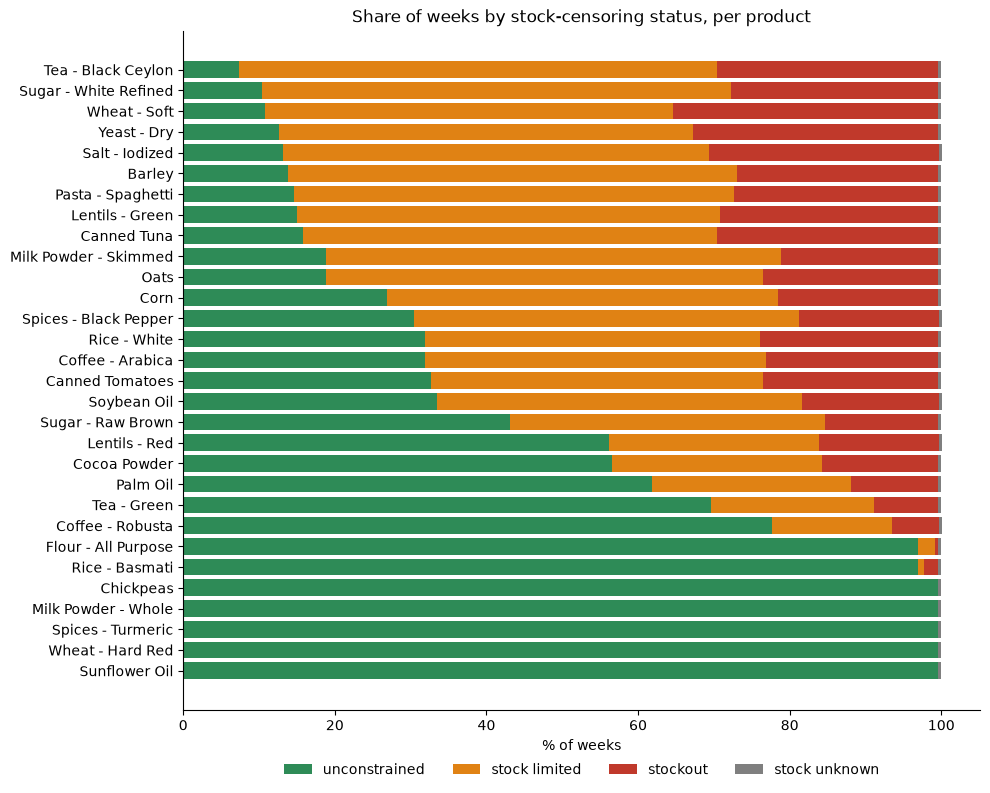

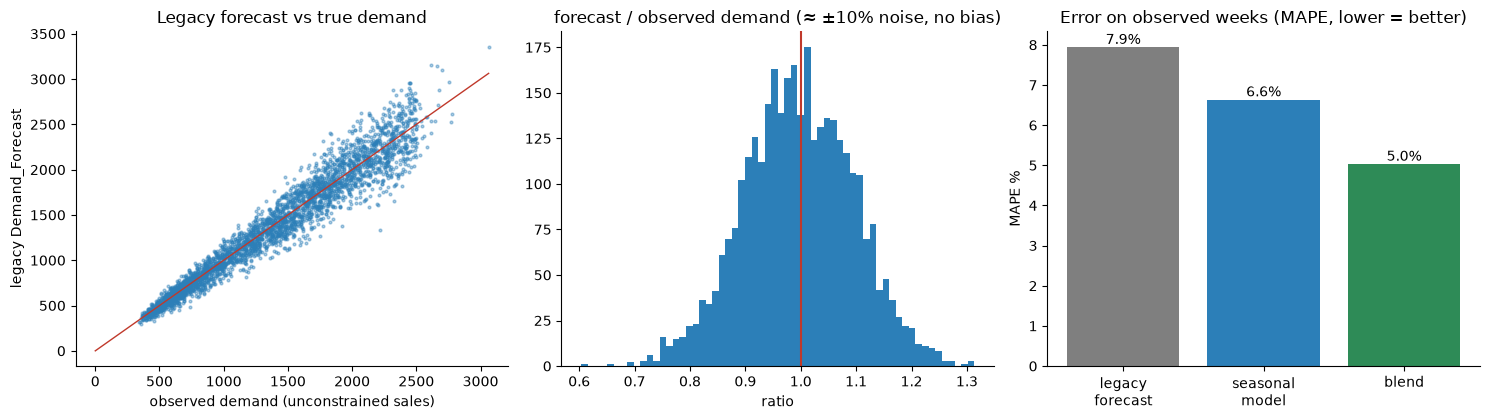

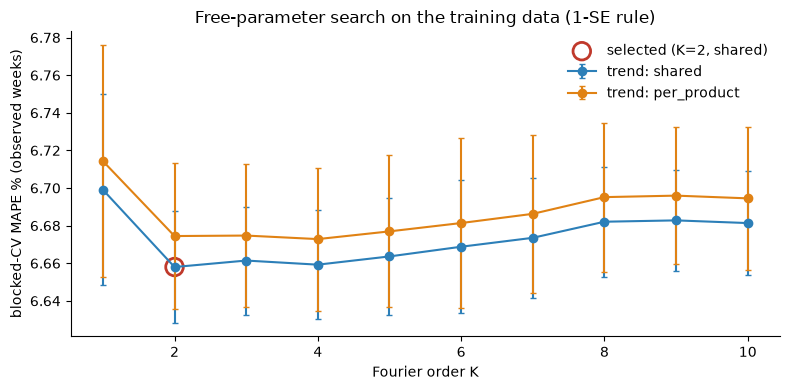

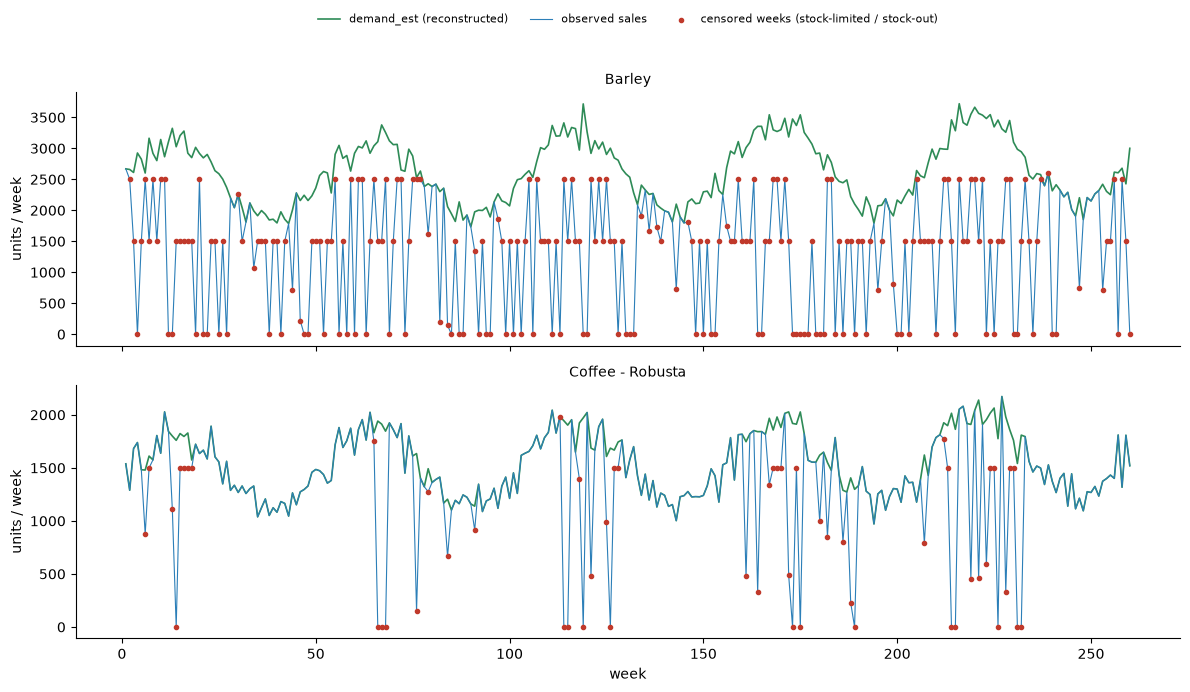

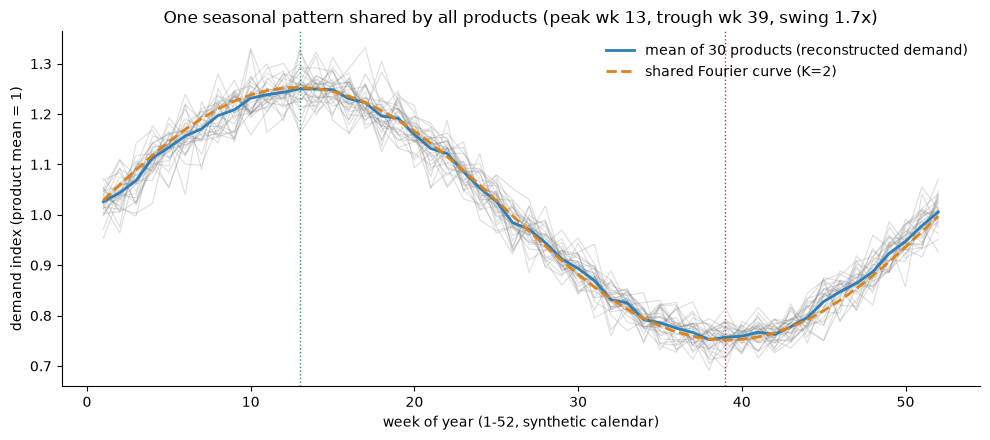

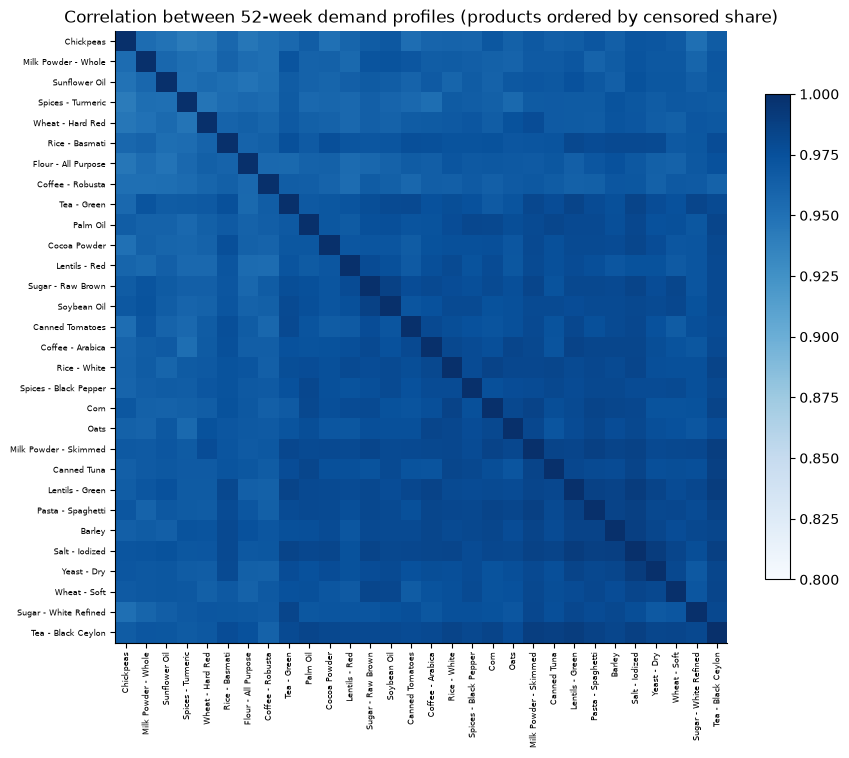

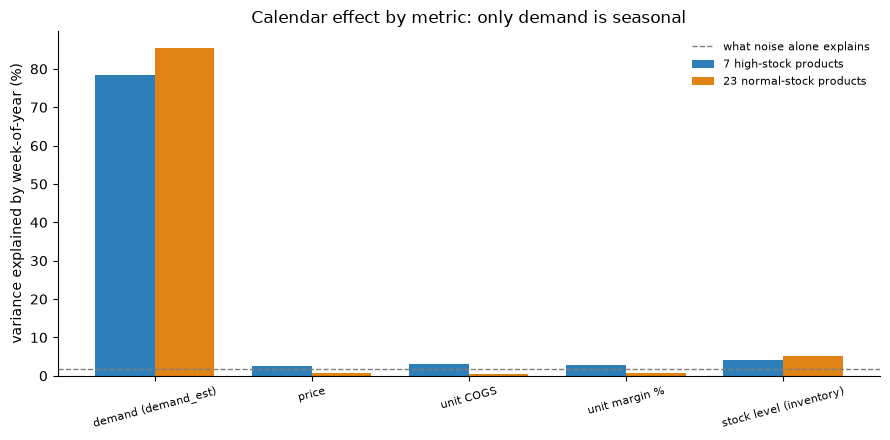

In [13]:
# 1) censoring share per product
fig, ax = plt.subplots(figsize=(10, 8))
cb = cens_by_product[order].iloc[::-1]
left = np.zeros(len(cb))
for col, color in zip(order, [GREEN, ORANGE, RED, GREY]):
    ax.barh(cb.index, cb[col], left=left, color=color, label=col.replace("_", " ")); left += cb[col].values
ax.set_xlabel("% of weeks"); ax.set_title("Share of weeks by stock-censoring status, per product"); ax.legend(ncol=4, frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.06))
fig.tight_layout(); fig.savefig(FIG / f"censoring_by_product_{VERSION}.png"); plt.show()

# 2) legacy forecast vs observed demand + validation of reconstruction
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
axes[0].scatter(u.sales_units, u.demand_forecast_legacy, s=4, alpha=.4, color=BLUE); lim = [0, u.sales_units.max()]
axes[0].plot(lim, lim, color=RED, lw=1); axes[0].set_xlabel("observed demand (unconstrained sales)"); axes[0].set_ylabel("legacy Demand_Forecast"); axes[0].set_title("Legacy forecast vs true demand")
axes[1].hist(u.ratio.clip(0.5, 1.6), bins=60, color=BLUE); axes[1].axvline(1, color=RED); axes[1].set_title("forecast / observed demand (≈ ±10% noise, no bias)"); axes[1].set_xlabel("ratio")
rv = recon_validation["MAPE_%"]; axes[2].bar(["legacy\nforecast", "seasonal\nmodel", "blend"], rv.values, color=[GREY, BLUE, GREEN])
for i, v in enumerate(rv.values): axes[2].text(i, v, f"{v:.1f}%", ha="center", va="bottom")
axes[2].set_title("Error on observed weeks (MAPE, lower = better)"); axes[2].set_ylabel("MAPE %")
fig.tight_layout(); fig.savefig(FIG / f"legacy_forecast_validation_{VERSION}.png"); plt.show()

# 3) hyper-parameter search of the seasonal model
fig, ax = plt.subplots(figsize=(8, 4))
for mode, color in zip(CFG["trend_modes"], [BLUE, ORANGE]):
    s = imp_cv[imp_cv.trend == mode]; ax.errorbar(s.K, s["cv_MAPE_%"], yerr=s.cv_SE, marker="o", color=color, label=f"trend: {mode}", capsize=2)
ax.scatter([K_OPT], [chosen["cv_MAPE_%"]], s=160, facecolors="none", edgecolors=RED, lw=2, label=f"selected (K={K_OPT}, {TREND_OPT})")
ax.set_xlabel("Fourier order K"); ax.set_ylabel("blocked-CV MAPE % (observed weeks)"); ax.set_title("Free-parameter search on the training data (1-SE rule)"); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(FIG / f"model_param_search_{VERSION}.png"); plt.show()

# 4) reconstruction examples
ex = [dim_prod.sort_values("product_id").query("inventory_profile == 'normal'").product_name.iloc[i] for i in (0, 5)]
fig, axes = plt.subplots(len(ex), 1, figsize=(12, 7), sharex=True)
for ax, p in zip(axes, ex):
    g = df[df.product_name == p]
    ax.plot(g.week_id, g.demand_est, color=GREEN, lw=1.2, label="demand_est (reconstructed)")
    ax.plot(g.week_id, g.sales_units, color=BLUE, lw=.8, label="observed sales")
    cc = g[g.is_censored == 1]; ax.scatter(cc.week_id, cc.sales_units, s=9, color=RED, label="censored weeks (stock-limited / stock-out)", zorder=3)
    ax.set_title(p, fontsize=10); ax.set_ylabel("units / week")
axes[0].legend(ncol=3, frameon=False, fontsize=8, loc="upper center", bbox_to_anchor=(0.5, 1.35)); axes[-1].set_xlabel("week")
fig.tight_layout(); fig.savefig(FIG / f"demand_reconstruction_examples_{VERSION}.png"); plt.show()

# 5) common seasonal curve
fig, ax = plt.subplots(figsize=(10, 4.5))
for p in prof.columns: ax.plot(prof.index, prof[p], color=GREY, alpha=.25, lw=.8)
ax.plot(seasonal_curve.week_of_year, seasonal_curve.empirical_index, color=BLUE, lw=2, label="mean of 30 products (reconstructed demand)")
ax.plot(seasonal_curve.week_of_year, seasonal_curve.model_index, color=ORANGE, lw=2, ls="--", label=f"shared Fourier curve (K={K_OPT})")
ax.axvline(peak_w, color=GREEN, lw=1, ls=":"); ax.axvline(trough_w, color=RED, lw=1, ls=":")
ax.set_xlabel("week of year (1-52, synthetic calendar)"); ax.set_ylabel("demand index (product mean = 1)"); ax.set_title(f"One seasonal pattern shared by all products (peak wk {peak_w}, trough wk {trough_w}, swing {swing:.1f}x)"); ax.legend(frameon=False)
fig.tight_layout(); fig.savefig(FIG / f"seasonal_curve_{VERSION}.png"); plt.show()

# 6) profile-correlation heatmap
fig, ax = plt.subplots(figsize=(9, 8))
ordr = prof_corr.index[np.argsort(pp.loc[prof_corr.index, "censored_share"].values)]
im = ax.imshow(prof_corr.loc[ordr, ordr], cmap="Blues", vmin=0.8, vmax=1); ax.set_xticks(range(30)); ax.set_xticklabels(ordr, rotation=90, fontsize=6); ax.set_yticks(range(30)); ax.set_yticklabels(ordr, fontsize=6)
fig.colorbar(im, shrink=.7); ax.set_title("Correlation between 52-week demand profiles (products ordered by censored share)")
fig.tight_layout(); fig.savefig(FIG / f"profile_correlation_{VERSION}.png"); plt.show()

# 7) calendar effects
w52 = cal_effects[cal_effects.calendar == "week_of_year"]
fig, ax = plt.subplots(figsize=(9, 4.5)); xs = np.arange(len(metrics_cal)); wd = 0.38
for i, (g, color) in enumerate(zip(groups, [BLUE, ORANGE])):
    s = w52[w52.group == g].set_index("metric").loc[list(metrics_cal)]
    ax.bar(xs + (i - .5) * wd, s.R2_observed * 100, wd, color=color, label=g)
ax.set_xticks(xs); ax.set_xticklabels(list(metrics_cal), rotation=15, fontsize=8); ax.axhline(100 * w52.R2_null_mean.mean(), color=GREY, ls="--", lw=1, label="what noise alone explains")
ax.set_ylabel("variance explained by week-of-year (%)"); ax.set_title("Calendar effect by metric: only demand is seasonal"); ax.legend(frameon=False, fontsize=8)
fig.tight_layout(); fig.savefig(FIG / f"calendar_effects_{VERSION}.png"); plt.show()

## 9. Export everything to one Excel file
`part2_preprocessing_v1.0/preprocessing_results_v1.0.xlsx` – Summary (first sheet), stock censoring, legacy-forecast validation, free-parameter search, reconstruction validation, calendar effects, seasonal curve, product patterns, regimes, data dictionary, assumptions, the demand panel and figures.

In [14]:
from openpyxl import load_workbook
from openpyxl.drawing.image import Image as XLImage
from openpyxl.styles import Alignment, Font, PatternFill
from openpyxl.utils import get_column_letter

mat = cal_effects[(cal_effects.calendar == "week_of_year") & cal_effects["material (R2 > 5%)"]]
mat_txt = "; ".join(f"{r.metric} ({r.group.split(' ')[0]}): {100 * r.R2_observed:.0f}%" for r in mat.itertuples()) or "none"
cm_ = cens_by_profile
bo = best
summary = pd.DataFrame([
    ("Input", "ETL v1.1 database", f"{len(df):,} product-weeks, {df.product_id.nunique()} products, 260 weeks", "Read from part1_etl_pipeline_v1.1; integrity asserts passed (no sales > available stock)"),
    ("Censoring", "Weeks by stock status", f"unconstrained {cens_overall.loc['unconstrained','pct']}%, stock-limited {cens_overall.loc['stock_limited','pct']}%, stock-out {cens_overall.loc['stockout','pct']}%, unknown {cens_overall.loc['stock_unknown','pct']}%", "Observed sales are NOT demand in censored weeks"),
    ("Censoring", "High-stock (7) vs normal-stock (23) products", f"unconstrained {cm_.loc['high_stock','unconstrained']}% vs {cm_.loc['normal','unconstrained']}%", "The 7 products are never capped; the 23 are capped ~2/3 of the time"),
    ("Legacy forecast", "Accuracy vs true demand (unconstrained weeks)", f"MAPE {legacy_overall.loc['unconstrained weeks','MAPE_%']:.1f}%, bias {legacy_overall.loc['unconstrained weeks','bias_%']:.1f}%, corr {legacy_overall.loc['unconstrained weeks','corr']:.2f}", "Unbiased, ~10% multiplicative noise -> usable as a measure of true demand"),
    ("Legacy forecast", "Missing values", f"{int(df.demand_forecast_legacy.isna().sum())} rows ({100 * df.demand_forecast_legacy.isna().mean():.1f}%)", "Filled by the seasonal model where weeks are censored"),
    ("Free parameters", "Seasonal model: Fourier order K and trend structure", f"K = {K_OPT}, trend = {TREND_OPT} (best CV: K={int(bo.K)}, {bo.trend})", f"Chosen by blocked {CFG['n_folds']}-fold CV on training data with the 1-SE rule; CV MAPE {chosen['cv_MAPE_%']:.2f}%"),
    ("Free parameters", "Blend weight on legacy forecast", f"w = {W:.2f}", f"Fitted on out-of-fold predictions; held-out-product check {w_halves[0][0]:.2f} / {w_halves[1][0]:.2f}"),
    ("Reconstruction", "Error on observed weeks (MAPE): forecast / model / blend", " / ".join(f"{v:.1f}%" for v in recon_validation['MAPE_%']), "Blend is the most accurate demand measure for censored weeks" if recon_validation['MAPE_%'].idxmin().startswith('blend') else "See Reconstruction_Validation"),
    ("Reconstruction", "Demand source counts", ", ".join(f"{k} {v:,}" for k, v in df.demand_source.value_counts().items()), f"Estimated lost demand {lost.sum():,.0f} units = {100 * lost.sum() / df.demand_est.sum():.1f}% of reconstructed demand"),
    ("Seasonality", "Shared yearly curve", f"peak wk {peak_w}, trough wk {trough_w}, swing {swing:.2f}x; growth {growth_yoy.mean():.1f}% per year", "All 30 products follow the same pattern (see Product_Profiles / Profile_Corr)"),
    ("Calendar effects", "Week-of-year share of variance (material, > 5%)", mat_txt, "Price, COGS and unit margin have no calendar effect; stock level only a small one"),
    ("Product shape", "Similarity of 52-week profiles", f"mean pairwise corr {tri.mean():.2f} (min {tri.min():.2f}); best silhouette {shape_clusters.silhouette.max():.2f}", "Shapes are nearly identical -> sub-clusters by shape add little; clusters are still compared as a modelling approach"),
    ("Stock regimes", "Clusters of stock-out behaviour", f"{K_REG} regimes (silhouette {regime_search.silhouette.max():.2f})", "Regimes R1..R%d from least to most capped; used for stock-out risk and as model feature" % K_REG),
    ("Output", "Forecasting dataset", f"demand_panel {demand_panel.shape[0]:,} rows, calendar_future 26 weeks, last_known 30 products", "Written to forecast_dataset_v1.0.db for the forecasting notebook"),
], columns=["Area", "Check / step", "Result", "Conclusion / treatment"])
summary.insert(0, "#", range(1, len(summary) + 1))

DESC = {
    "stock_regime": "Stock-out behaviour cluster R1 (rarely capped) .. R_k (often capped)", "censor_status": "unconstrained / stock_limited / stockout / stock_unknown",
    "demand_est": "RECONSTRUCTED DEMAND = forecasting target (observed sales when unconstrained, else max(sales, blend))",
    "demand_source": "observed / forecast_blend / model_only", "demand_uplift_pct": "100 * (demand_est / sales - 1)",
    "model_pred": "Seasonal-model prediction (shared curve x product level x trend)", "stock_available_for_sales": "Previous row's inventory (stock limiting this week's sales)",
    "sales_units": "Observed sales (= min(demand, stock))", "demand_forecast_legacy": "Legacy forecast from the source (NULL = missing)",
    "week_of_year": "1..52 position within the data year", "year_index": "Data year 1..5 (52-week blocks)",
}
dd = pd.DataFrame({"column": demand_panel.columns, "dtype": [str(t) for t in demand_panel.dtypes]})
dd["description"] = dd.column.map(DESC).fillna("")
assumptions = pd.DataFrame([
    ("P1", "Target", "Forecast latent demand (demand_est), not observed sales; expected sales = min(demand, stock) is derived later."),
    ("P2", "Unconstrained weeks", "Sales < stock available => sales equal true demand (stock never binds)."),
    ("P3", "Censored weeks", "Sales = stock available (or 0 with stock 0) => demand >= sales; reconstructed as max(sales, blend)."),
    ("P4", "Legacy forecast", "Treated as a noisy (~10%), unbiased measure of demand; validated on unconstrained weeks only."),
    ("P5", "Selection effect", "Unconstrained weeks are slightly biased to lower-demand weeks (demand < stock); the blend weight is a low-risk 1-parameter fit."),
    ("P6", "Seasonal model", "Log-linear, one shared Fourier seasonal curve for all products (justified by profile correlation) + product level + trend; K and trend structure tuned by blocked CV."),
    ("P7", "Calendar", "Synthetic dates (week 1 = 2020-01-06); 'month'/'season' labels are illustrative, week-of-year (1-52) is the real cycle position."),
    ("P8", "Forecast horizon", "26 weeks after week 260 (weeks 261-286); price / COGS held at their last-13-week mean for scenarios; future stock is unknown."),
], columns=["#", "Topic", "Assumption"])

sheets = {
    "Summary": summary, "Censoring_Overall": cens_overall.reset_index().rename(columns={"index": "status", "censor_status": "status"}),
    "Censoring_By_Profile": cens_by_profile.reset_index(), "Censoring_By_Product": cens_by_product.reset_index(),
    "Legacy_Validation": legacy_overall.round(3).reset_index().rename(columns={"index": "subset"}),
    "Legacy_By_Product": legacy_by_product.reset_index(), "Legacy_On_Censored": fc_vs_censored,
    "Param_Search_CV": imp_cv.round(4), "Reconstruction_Validation": recon_validation.reset_index().rename(columns={"index": "method"}),
    "Demand_Source_Counts": src_counts.reset_index(), "Lost_Demand_By_Product": lost_by_product.round(1).reset_index(),
    "Calendar_Effects": cal_effects.round(4), "Seasonal_Curve": seasonal_curve.round(4),
    "Shape_Similarity": shape_summary, "Shape_Clusters": shape_clusters.round(3).assign(cluster_sizes=lambda x: x.cluster_sizes.astype(str)),
    "Profile_Corr": prof_corr.round(3).reset_index(), "Stock_Regime_Search": regime_search.round(3), "Stock_Regimes": regime_summary.reset_index(),
    "Product_Profiles": product_profile, "Last_Known": last_known, "Calendar_Future": calendar_future,
    "Data_Dictionary": dd, "Assumptions": assumptions, "demand_panel": demand_panel,
}
with pd.ExcelWriter(XLSX_PATH, engine="openpyxl") as xw:
    for name, t in sheets.items():
        t.to_excel(xw, sheet_name=name[:31], index=False)
wb = load_workbook(XLSX_PATH)
head_fill = PatternFill("solid", fgColor="1F4E79")
for ws in wb.worksheets:
    for cell in ws[1]:
        cell.font = Font(bold=True, color="FFFFFF"); cell.fill = head_fill; cell.alignment = Alignment(horizontal="center", vertical="center")
    ws.freeze_panes = "A2"
    for i, col in enumerate(ws.columns, 1):
        width = max(len(str(c.value)) if c.value is not None else 0 for c in list(col)[:300])
        ws.column_dimensions[get_column_letter(i)].width = min(max(width + 2, 8), 60)
for name, widths in {"Summary": [5, 16, 44, 62, 80], "Assumptions": [6, 22, 140], "Data_Dictionary": [28, 12, 100]}.items():
    for col, w in zip("ABCDE", widths):
        wb[name].column_dimensions[col].width = w
    for r in wb[name].iter_rows(min_row=2):
        for c in r: c.alignment = Alignment(wrap_text=True, vertical="top")
fs = wb.create_sheet("Figures")
row = 1
for png in sorted(FIG.glob(f"*_{VERSION}.png")):
    fs.cell(row=row, column=1, value=png.name).font = Font(bold=True)
    img = XLImage(str(png)); scale = 640 / img.width
    img.width, img.height = 640, int(img.height * scale)
    fs.add_image(img, f"A{row + 1}")
    row += int(img.height / 20) + 4
wb.save(XLSX_PATH)
print("Saved:", XLSX_PATH.name, "| sheets:", len(wb.sheetnames))

Saved: preprocessing_results_v1.0.xlsx | sheets: 25


## 10. Outputs created by this notebook
| File | Purpose |
|---|---|
| `part2_preprocessing_v1.0/forecast_dataset_v1.0.db` | `demand_panel`, `product_profile`, `calendar_future`, `last_known`, `seasonal_curve`, `preprocessing_params` – input of the forecasting notebook |
| `part2_preprocessing_v1.0/preprocessing_results_v1.0.xlsx` | All results in one workbook (first sheet = Summary) |
| `part2_preprocessing_v1.0/figures/*_v1.0.png` | Charts |